# Programming Python for Bioinformatics (WBT-MBT2-25E)

---

### Wojciech Dec
<br>

### Part 6 - Introduction to Structural Bioinformatics

This notebook introduces working with structural data, including downloading and reading protein structure files, and using the RCSB PDB Data API to retrieve information for a given PDB entry.

---

In structural biology, experimentally determined protein structures are commonly stored in *Macromolecular Crystallographic Information Files (mmCIF)*. This format is used by the **Protein Data Bank (PDB)** as the standard way to distribute structural data.

An mmCIF file contains much more than just atom coordinates. It typically includes:
 * Atomic structure — positions of all atoms in 3D space
 * Macromolecular hierarchy — models, chains, residues, atoms
 * Experimental details — method (e.g. X-ray crystallography, cryo-EM)
 * Quality indicators — resolution, R-factors, B-factors
 * Annotations — ligands, secondary structure, biological assembly

**Biopython** is a versatile tool that can be used for interacting with structural data; however, more specialised libraries like **Gemmi** offer more features and better performance. Let’s compare how to access data from an mmCIF file using both libraries. First, let's download a protein structure!

In [60]:
import requests
from pathlib import Path

def download_pdb(pdb_id, file_format="cif", save_dir="."):
    """
    Download a structure file from the Protein Data Bank (PDB).

    Parameters:
        pdb_id (str): 4-character PDB ID (e.g., '1TUP')
        file_format (str): 'pdb', 'cif', or 'xml'
        save_dir (str or Path): Directory to save the file

    Returns:
        Path: Path to the saved file
    """
    pdb_id = pdb_id.lower()
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    url = f"https://files.rcsb.org/download/{pdb_id}.{file_format}"
    file_path = save_dir / f"{pdb_id}.{file_format}"

    with requests.get(url, stream=True) as response:
        if response.status_code != 200:
            raise Exception(f"Failed to download {pdb_id}: HTTP {response.status_code}")

        with open(file_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

    return file_path

In [16]:
import gemmi
from time import perf_counter
from Bio.PDB import MMCIFParser


def read_with_gemmi(cif_path):
    start = perf_counter()
    structure = gemmi.read_structure(cif_path)
    elapsed = perf_counter() - start

    model_count = len(structure)
    chain_count = 0
    residue_count = 0
    atom_count = 0

    for model in structure:
        for chain in model:
            chain_count += 1
            for residue in chain:
                residue_count += 1
                atom_count += len(residue)

    return {
        "library": "Gemmi",
        "time_seconds": elapsed,
        "models": model_count,
        "chains": chain_count,
        "residues": residue_count,
        "atoms": atom_count,
        "structure": structure,
    }


def read_with_biopython(cif_path):
    parser = MMCIFParser(QUIET=True)
    pdb_id = Path(cif_path).stem

    start = perf_counter()
    structure = parser.get_structure(pdb_id, cif_path)
    elapsed = perf_counter() - start

    model_count = 0
    chain_count = 0
    residue_count = 0
    atom_count = 0

    for model in structure:
        model_count += 1
        for chain in model:
            chain_count += 1
            for residue in chain:
                residue_count += 1
                for atom in residue:
                    atom_count += 1

    return {
        "library": "BioPython",
        "time_seconds": elapsed,
        "models": model_count,
        "chains": chain_count,
        "residues": residue_count,
        "atoms": atom_count,
        "structure": structure,
    }


def print_summary(result):
    print(f"\n--- {result['library']} ---")
    print(f"Time to open file: {result['time_seconds']:.6f} seconds")
    print(f"Number of models:  {result['models']}")
    print(f"Number of chains:  {result['chains']}")
    print(f"Number of residues:{result['residues']}")
    print(f"Number of atoms:   {result['atoms']}")

    
    
cif_path = download_pdb("1huj")
gemmi_result = read_with_gemmi(str(cif_path))
biopython_result = read_with_biopython(str(cif_path))
print_summary(gemmi_result)
print_summary(biopython_result)


--- Gemmi ---
Time to open file: 0.009068 seconds
Number of models:  1
Number of chains:  2
Number of residues:877
Number of atoms:   4811

--- BioPython ---
Time to open file: 0.162118 seconds
Number of models:  1
Number of chains:  2
Number of residues:877
Number of atoms:   4811


Let’s iterate over all atoms in the model by following the molecular hierarchy and check if any atoms have b-factor value above 100.

In [20]:
structure = gemmi.read_structure(str(cif_path)) # unfortunetly gemmi doesn't work with pathlib Path objects..

for model in structure:
    for chain in model:
        for residue in chain:
            for atom in residue:
                if atom.b_iso >= 100:
                    print(f"{chain.name} {residue.name} {residue.seqid.num} {atom.element.name} {atom.b_iso}")


B HOH 403 O 101.4000015258789


Let’s visualise the B-factor along the protein chain using only Cα atoms. Instead of itereting over all atoms we can use methods such as `get_polymer()` to get what we need.

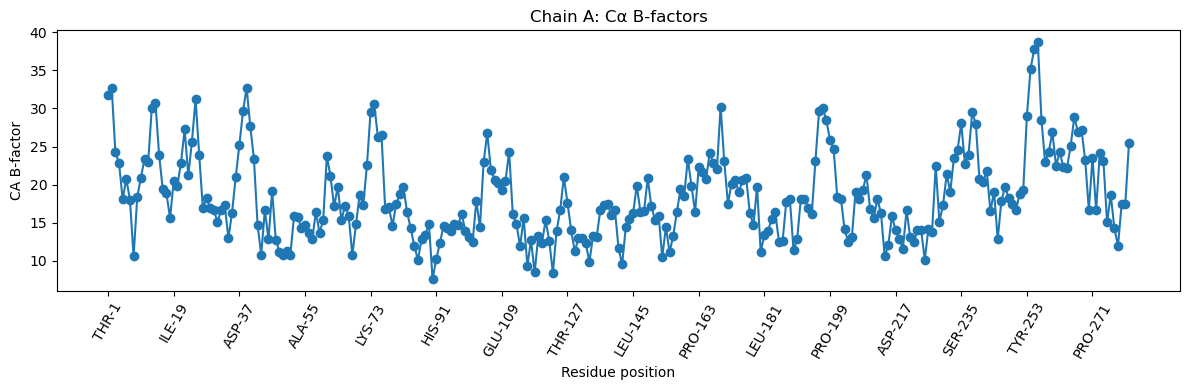

In [21]:
import matplotlib.pyplot as plt

cif_file = "1huj.cif"
chain_id = "A"

st = gemmi.read_structure(cif_file)
chain = st[0][chain_id]
polymer = chain.get_polymer()

x = []
y = []
labels = []

for i, residue in enumerate(polymer.first_conformer(), start=1):
    ca = residue.find_atom("CA", "*")
    if ca is not None:
        x.append(i)
        y.append(ca.b_iso)
        labels.append(f"{residue.name}-{residue.seqid.num}")

plt.figure(figsize=(12, 4))
plt.plot(x, y, marker="o")
plt.xlabel("Residue position")
plt.ylabel("CA B-factor")
plt.title(f"Chain {chain_id}: Cα B-factors")

step = max(1, len(labels) // 15)
plt.xticks(x[::step], labels[::step], rotation=60)
plt.tight_layout()
plt.show()

We can also easily download an AlphaFold-predicted structure as follows (if it is available in AFDB). In predicted structure mmCIF files, the B-factor field is replaced by predicted local distance difference test (pLDDT) values. Let’s plot these below.

In [68]:
from pathlib import Path
import requests
import json

def download_alphafold_model(accession, save_dir=".", file_format="cif"):
    """
    Download an AlphaFold DB predicted model for a UniProt accession.

    Parameters
    ----------
    accession : str
        UniProt accession (e.g. "P00817")
    save_dir : str or Path
        Directory where files will be saved
    file_format : str
        'cif'

    Returns
    -------
    Path
        Path to the downloaded structure file
    """
    accession = accession.strip().upper()
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    model_path = save_dir / f"{accession}.{file_format}"
    data_path = save_dir / f"{accession}.json"

    # Already downloaded
    if model_path.exists():
        return model_path

    # Load or fetch metadata
    if data_path.exists():
        with data_path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    else:
        api_url = f"https://alphafold.ebi.ac.uk/api/prediction/{accession}"
        response = requests.get(api_url, timeout=30)
        response.raise_for_status()
        data = response.json()

        with data_path.open("w", encoding="utf-8") as f:
            json.dump(data, f, indent=2)

    # Validate response
    if not isinstance(data, list) or not data:
        raise ValueError(f"No AlphaFold data found for accession {accession}")

    file_url = data[0].get("cifUrl")
    if not file_url:
        raise ValueError(f"No {file_format} URL found for accession {accession}")

    # Download with streaming
    with requests.get(file_url, stream=True, timeout=60) as response:
        response.raise_for_status()
        with model_path.open("wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

    return model_path

In [69]:
af_model_path = download_alphafold_model("P00817")

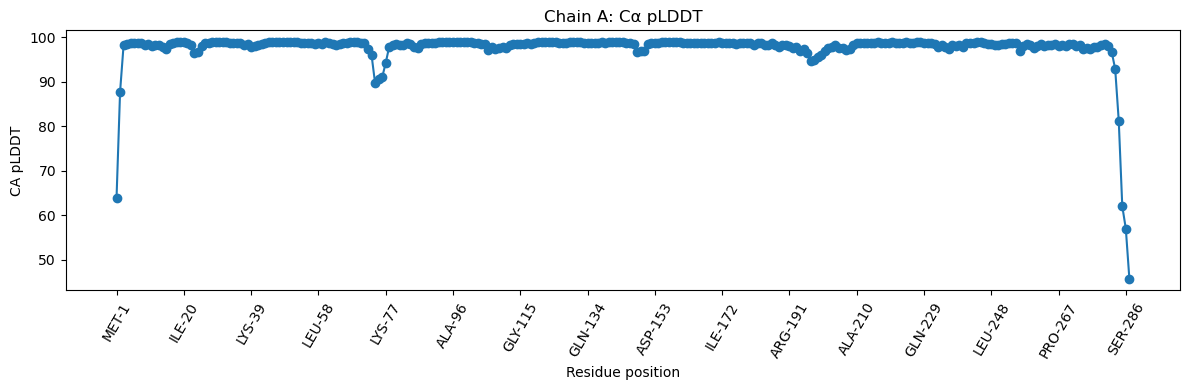

In [71]:
cif_file = "P00817.cif"
chain_id = "A"

st = gemmi.read_structure(cif_file)
chain = st[0][chain_id]
polymer = chain.get_polymer()

x = []
y = []
labels = []

for i, residue in enumerate(polymer.first_conformer(), start=1):
    ca = residue.find_atom("CA", "*")
    if ca is not None:
        x.append(i)
        y.append(ca.b_iso)
        labels.append(f"{residue.name}-{residue.seqid.num}")

plt.figure(figsize=(12, 4))
plt.plot(x, y, marker="o")
plt.xlabel("Residue position")
plt.ylabel("CA pLDDT")
plt.title(f"Chain {chain_id}: Cα pLDDT")

step = max(1, len(labels) // 15)
plt.xticks(x[::step], labels[::step], rotation=60)
plt.tight_layout()
plt.show()

Gemmi offers many ways to search an mmCIF file; for example, we can access fields of interest directly as follows:

In [77]:
doc = gemmi.cif.read("1huj.cif")
block = doc.sole_block()

pub_title = block.find_values('_citation.title')
journal_name = block.find_values('_citation.journal_abbrev')
seq = block.find_values('_entity_poly.pdbx_seq_one_letter_code')
initial_model = block.find_values('_pdbx_initial_refinement_model.accession_code')

print("Publication title: ", pub_title[0])
print("Journal name: ", journal_name[0])
print("Protein sequence: ", seq[0])
print("Initial model: ", initial_model[0])

Publication title:  'Refined Structure of Yeast Inorganic Pyrophosphatase and its K61R Mutant'
Journal name:  'To be Published'
Protein sequence:  ;TYTTRQIGAKNTLEYKVYIEKDGKPVSAFHDIPLYADKENNIFNMVVEIPRWTNAKLEITREETLNPIIQDTKKGKLRFV
RNCFPHHGYIHNYGAFPQTWEDPNVSHPETKAVGDNDPIDVLEIGETIAYTGQVKQVKALGIMALLDEGETDWKVIAIDI
NDPLAPKLNDIEDVEKYFPGLLRATNEWFRIYKIPDGKPENQFAFSGEAKNKKYALDIIKETHDSWKQLIAGKSSDSKGI
DLTNVTLPDTPTYSKAASDAIPPASLKADAPIDKSIDKWFF
;
Initial model:  1PYP


You can read more about data fields available in mmCIF files here https://mmcif.wwpdb.org/dictionaries/mmcif_pdbx_v50.dic/Index/.

You can read more about what Gemmi has to offer here: https://project-gemmi.github.io/python-api/index.html.

---

### RCSB PDB Data API

The RCSB PDB Data API, provided by the Protein Data Bank, allows programmatic access to structural and metadata associated with biomolecular structures. It enables users to retrieve information such as experimental methods, resolution, ligand details, and sequence annotations directly from the PDB.You can read more about the data available for download in the official documentation here https://data.rcsb.org/data-attributes.html.

In [23]:
from rcsbapi.data import DataQuery as Query

Let's use the GraphQL interface to retrive information about ligands in the 7PMZ entry.

In [49]:
input_ids = ["7PMZ"]

q = Query(
    input_type="entries",
    input_ids=input_ids,
    return_data_list=[
    "nonpolymer_entities.rcsb_id",
    "nonpolymer_entities.nonpolymer_entity_instances.rcsb_nonpolymer_entity_instance_container_identifiers.comp_id",
    "nonpolymer_entities.nonpolymer_entity_instances.rcsb_nonpolymer_instance_validation_score.ranking_model_fit",
    "nonpolymer_entities.nonpolymer_entity_instances.rcsb_nonpolymer_instance_validation_score.ranking_model_geometry",
    "nonpolymer_entities.nonpolymer_entity_instances.rcsb_nonpolymer_instance_validation_score.is_subject_of_investigation",
    "nonpolymer_entities.nonpolymer_comp.rcsb_chem_comp_descriptor.SMILES"
    ])
        
ligand_data = q.exec()

In [52]:
ligand_smiles = ligand_data['data']['entries'][0]['nonpolymer_entities'][0]['nonpolymer_comp']['rcsb_chem_comp_descriptor']['SMILES']

We can use **RDKit** (Open-Source Cheminformatics Software) to visualise the chemical structure of this ligand.

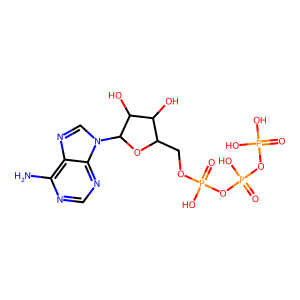

In [53]:
from rdkit import Chem
from rdkit.Chem import Draw

# It’s an ATP molecule!
Draw.MolToImage(Chem.MolFromSmiles(ligand_smiles))

We can now iterate over atoms:

In [91]:
for atom in mol.GetAtoms():
    print(
        "Idx:", atom.GetIdx(),
        "Symbol:", atom.GetSymbol(),
        "Atomic number:", atom.GetAtomicNum(),
        "Degree:", atom.GetDegree(),
        "Hybridization:", atom.GetHybridization()
    )

Idx: 0 Symbol: C Atomic number: 6 Degree: 3 Hybridization: SP2
Idx: 1 Symbol: N Atomic number: 7 Degree: 2 Hybridization: SP2
Idx: 2 Symbol: C Atomic number: 6 Degree: 3 Hybridization: SP2
Idx: 3 Symbol: C Atomic number: 6 Degree: 3 Hybridization: SP2
Idx: 4 Symbol: C Atomic number: 6 Degree: 3 Hybridization: SP2
Idx: 5 Symbol: N Atomic number: 7 Degree: 2 Hybridization: SP2
Idx: 6 Symbol: N Atomic number: 7 Degree: 3 Hybridization: SP2
Idx: 7 Symbol: C Atomic number: 6 Degree: 3 Hybridization: SP2
Idx: 8 Symbol: N Atomic number: 7 Degree: 2 Hybridization: SP2
Idx: 9 Symbol: C Atomic number: 6 Degree: 4 Hybridization: SP3
Idx: 10 Symbol: C Atomic number: 6 Degree: 4 Hybridization: SP3
Idx: 11 Symbol: C Atomic number: 6 Degree: 4 Hybridization: SP3
Idx: 12 Symbol: C Atomic number: 6 Degree: 4 Hybridization: SP3
Idx: 13 Symbol: O Atomic number: 8 Degree: 2 Hybridization: SP3
Idx: 14 Symbol: C Atomic number: 6 Degree: 4 Hybridization: SP3
Idx: 15 Symbol: O Atomic number: 8 Degree: 2 Hybri

Or iterate over the bonds:

In [93]:
for bond in mol.GetBonds():
    print(
        "Bond:", bond.GetBeginAtomIdx(), "-", bond.GetEndAtomIdx(),
        "Type:", bond.GetBondType()
    )
    break

Bond: 0 - 1 Type: AROMATIC


In [94]:
print("Number of atoms:", mol.GetNumAtoms())
print("Number of bonds:", mol.GetNumBonds())
print("Molecular formula:", Chem.rdMolDescriptors.CalcMolFormula(mol))

Number of atoms: 47
Number of bonds: 49
Molecular formula: C10H16N5O13P3


In [95]:
atom = mol.GetAtomWithIdx(0)

print("Neighbors of atom 0:")
for neighbor in atom.GetNeighbors():
    print(neighbor.GetSymbol(), neighbor.GetIdx())

Neighbors of atom 0:
N 1
N 5
H 31


In [97]:
for atom in mol.GetAtoms():
    print(f"{atom.GetSymbol()} → valence: {atom.GetTotalValence()}")
    break

C → valence: 4


We can go one step further and use `py3Dmol` to visualize and interact with the ligand’s 3D structure directly in the notebook.

In [57]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
from IPython.display import display


mol = Chem.MolFromSmiles(ligand_smiles)
mol = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol)
AllChem.MMFFOptimizeMolecule(mol)

mblock = Chem.MolToMolBlock(mol, kekulize=False)

view = py3Dmol.view(width=800, height=500)
view.addModel(mblock, "mol")
view.setStyle({"stick": {}, "sphere": {"scale": 0.25}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Or even view the protein structure.

In [58]:
with open("1huj.cif") as f:
    data = f.read()

view = py3Dmol.view(width=800, height=500)
view.addModel(data, "cif")

# Cartoon style for protein
view.setStyle({"cartoon": {"color": "spectrum"}})

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---

### ETE Toolkit

Leaf names and linked sequences:

P53_human    MEEPQSDPSV
P53_mouse    MEEPQSDLSV
P53_rat      MEEPQSDLSV
P53_fish     MDEAQSDVSV


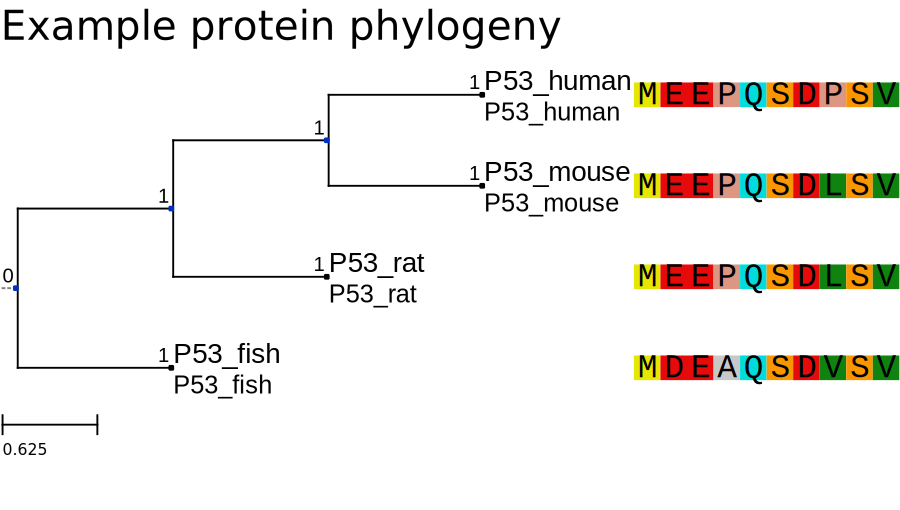

In [7]:
# This example assumes you already have ETE installed:
# pip install ete3

from ete3 import PhyloTree, TreeStyle, TextFace
from IPython.display import display, Image, SVG
import os

# 1) Example data
# Small protein alignment in FASTA format
fasta_txt = """>P53_human
MEEPQSDPSV
>P53_mouse
MEEPQSDLSV
>P53_rat
MEEPQSDLSV
>P53_fish
MDEAQSDVSV
"""

# Matching tree in Newick format
newick_txt = "(((P53_human,P53_mouse),P53_rat),P53_fish);"

# 2) Load the tree and link the alignment
# ETE supports passing the alignment directly when creating PhyloTree
t = PhyloTree(newick_txt, alignment=fasta_txt, alg_format="fasta")


# 3) Inspect linked sequences
print("Leaf names and linked sequences:\n")
for leaf in t.iter_leaves():
    print(f"{leaf.name:12s} {leaf.sequence}")


# 4) Create a tree style
ts = TreeStyle()
ts.show_leaf_name = True
ts.show_branch_length = True
ts.show_branch_support = False
ts.scale = 80
ts.branch_vertical_margin = 15

# Add a title
ts.title.add_face(TextFace("Example protein phylogeny", fsize=16), column=0)


# 5) Render to files
svg_file = "protein_tree.svg"
t.render(svg_file, w=900, tree_style=ts)


# 6) Display inline in Jupyter
display(SVG(filename=svg_file))

---

**Exercise 1.** Write a function that uses *Gemmi* to check whether any atoms in a given structure have an occupancy greater than 1 or equal to 0 (`Atom.occ`). Your function should print information about any such atoms, including the chain identifier, residue name, residue number, and atom name. Such occupancy values are not physically meaningful. Download the *mmCIF* file for the structure `4xtv` and analyze it using your function.

**Exercise 2.** Write a function that uses *Gemmi* to calculate the average B-factor for three groups of atoms (from a *mmCIF* file): polymer atoms (protein residues), ligand atoms (non-polymer, excluding water), and water molecules (you can use the `Residue.is_water()` method or the `Chain.get_waters()` method). Use only the first model in the structure. Exclude all hydrogen atoms from this calculation. You can access the B-factor of each atom using the `b_iso` attribute. Your program should print the average B-factor for each group.


The **B-factor** (or temperature factor) is a measure of how much an atom appears to move or be disordered in a crystal structure, with higher values indicating greater flexibility or uncertainty in its position.

**Exercise 3.** Write a function that uses *Gemmi* to extract basic information about a structure directly from an *mmCIF* file. Your function should read the CIF file using `gemmi.cif.read()` and access the data block. From the block, retrieve the following information:

* experimental method (`_exptl.method`)
* structure title (`_struct.title`)
* deposition date (`_pdbx_database_status.recvd_initial_deposition_date`)
* resolution (`_refine.ls_d_res_high`)

You can use the `find_values()` method to access these fields. Your function should return or print the extracted information in a readable format.

**Exercise 4.** Write a function that saves data retrieved by `get_polymer_entity_instance_features_from_rcsb` to a `.json` file. Then, parse the retrieved data to extract the list of RSRZ values calculated for each residue (feature with name or type or feature_id equal to "RSRZ").

RSRZ (Real-Space R-value Z-score) measures how well each residue fits the experimental electron density; values above 2.0 are typically considered outliers. Count how many residues exceed this threshold in the chosen structure.

The function `get_polymer_entity_instance_features_from_rcsb` takes a list of RCSB identifiers, constructed by joining the PDB ID and chain name with a dot. For example, you can call it with `["1HUJ.A"]`. The chosen structure must be determined using X-ray crystallography.

In [89]:
def get_polymer_entity_instance_features_from_rcsb(input_ids, input_type="polymer_entity_instance"):
    q = Query(
        input_type=input_type,
        input_ids=input_ids,
        return_data_list=[
            "polymer_entity.entry.polymer_entities.rcsb_id",
            "polymer_entity.entity_poly.pdbx_strand_id",
            "polymer_entity.entry.assemblies.rcsb_assembly_feature.feature_positions.asym_id",
            "rcsb_polymer_instance_feature.feature_id",
            "rcsb_polymer_instance_feature.name",
            "rcsb_polymer_instance_feature.type",
            "rcsb_polymer_instance_feature.feature_positions.beg_comp_id",
            "rcsb_polymer_instance_feature.feature_positions.beg_seq_id",
            "rcsb_polymer_instance_feature.feature_positions.end_seq_id",
            "rcsb_polymer_instance_feature.feature_positions.value",
            "rcsb_polymer_instance_feature.feature_positions.values",
    ])
        
    query_data = q.exec()

    return query_data